# Nested LOOCV statistical evaluation

## Lasso classifier

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score,roc_curve
from MLstatkit import Delong_test,Bootstrapping
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index
from scipy.stats import chi2
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Set ALL linewidths to 1.0
    "lines.linewidth": 1.4,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "ytick.major.size": 1.5,
    "xtick.major.size": 1.5,
    "grid.linewidth": 0.8,
    "axes.titlepad": 0.5,
    "axes.labelpad": 1,
    "savefig.pad_inches": 0.1
})
pred_df = pd.read_csv("./results/lasso/loo_nested_five_feature_lasso_paired_predictions.csv")
pred_df.columns

Index(['sample_name', 'sample_id', 'y_true', 'outer_fold', 'graph_y_pred',
       'nuclei_y_pred', 'gland_y_pred', 'nuclei_gland_y_pred',
       'nuclei_gland_graph_y_pred'],
      dtype='object')

In [3]:
# ============================================================
# 1. Paired stratified bootstrap for Delta AUC
# ============================================================

def paired_bootstrap_auc(
    y_true,
    pred_a,
    pred_b,
    n_boot=5000,
    confidence_level=0.95,
    random_state=42,
):
    """
    Paired stratified bootstrap CI for:
        Delta AUC = AUC_A - AUC_B

    Patients are resampled with replacement while keeping
    pred_a and pred_b paired for each patient.

    Positive and negative patients are resampled separately.
    """

    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)

    rng = np.random.default_rng(random_state)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]

    auc_a = roc_auc_score(y_true, pred_a)
    auc_b = roc_auc_score(y_true, pred_b)
    delta_auc = auc_a - auc_b

    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):

        # Stratified resampling
        boot_pos = rng.choice(
            pos_idx,
            size=len(pos_idx),
            replace=True,
        )

        boot_neg = rng.choice(
            neg_idx,
            size=len(neg_idx),
            replace=True,
        )

        idx = np.concatenate([boot_pos, boot_neg])

        boot_auc_a = roc_auc_score(
            y_true[idx],
            pred_a[idx],
        )

        boot_auc_b = roc_auc_score(
            y_true[idx],
            pred_b[idx],
        )

        boot_diffs[i] = boot_auc_a - boot_auc_b

    alpha = 1 - confidence_level

    ci_low, ci_high = np.percentile(
        boot_diffs,
        [
            100 * alpha / 2,
            100 * (1 - alpha / 2),
        ],
    )

    return delta_auc, ci_low, ci_high, boot_diffs


# ============================================================
# 2. Paired permutation test for Delta AUC
# ============================================================

def paired_permutation_auc(
    y_true,
    pred_a,
    pred_b,
    n_perm=10000,
    random_state=42,
):
    """
    Two-sided paired permutation test for:
        H0: AUC_A = AUC_B

    Within each patient, predictions from model A and model B
    are randomly swapped.
    """

    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)

    rng = np.random.default_rng(random_state)

    auc_a = roc_auc_score(y_true, pred_a)
    auc_b = roc_auc_score(y_true, pred_b)

    observed_diff = auc_a - auc_b

    perm_diffs = np.empty(n_perm)

    for i in range(n_perm):

        swap = rng.random(len(y_true)) < 0.5

        perm_a = pred_a.copy()
        perm_b = pred_b.copy()

        perm_a[swap] = pred_b[swap]
        perm_b[swap] = pred_a[swap]

        perm_diffs[i] = (
            roc_auc_score(y_true, perm_a)
            - roc_auc_score(y_true, perm_b)
        )

    # Two-sided permutation p-value
    p_value = (
        np.sum(
            np.abs(perm_diffs)
            >= np.abs(observed_diff)
        )
        + 1
    ) / (n_perm + 1)

    return observed_diff, p_value, perm_diffs


# ============================================================
# 3. Run all statistical comparisons
# ============================================================

def compare_auc(
    y_true,
    pred_a,
    pred_b,
    n_boot=5000,
    n_perm=10000,
    random_state=42,
):

    y_true = np.asarray(y_true)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)

    if not (
        len(y_true)
        == len(pred_a)
        == len(pred_b)
    ):
        raise ValueError(
            "y_true, pred_a, and pred_b must have the same length."
        )

    # --------------------------------------------------------
    # AUCs
    # --------------------------------------------------------

    auc_a = roc_auc_score(y_true, pred_a)
    auc_b = roc_auc_score(y_true, pred_b)

    delta_auc = auc_a - auc_b

    # --------------------------------------------------------
    # Paired DeLong test
    # --------------------------------------------------------

    z, delong_p = Delong_test(
        y_true,
        pred_a,
        pred_b,
        return_ci=False,
        return_auc=False,
        verbose=0,
    )

    # --------------------------------------------------------
    # Paired stratified bootstrap
    # --------------------------------------------------------

    _, bootstrap_low, bootstrap_high, _ = (
        paired_bootstrap_auc(
            y_true,
            pred_a,
            pred_b,
            n_boot=n_boot,
            confidence_level=0.95,
            random_state=random_state,
        )
    )

    # --------------------------------------------------------
    # Paired permutation test
    # --------------------------------------------------------

    _, permutation_p, _ = paired_permutation_auc(
        y_true,
        pred_a,
        pred_b,
        n_perm=n_perm,
        random_state=random_state,
    )

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    print("=" * 60)
    print("Paired AUC comparison")
    print("=" * 60)

    print(f"AUC A              : {auc_a:.4f}")
    print(f"AUC B              : {auc_b:.4f}")
    print(f"Delta AUC (A - B)  : {delta_auc:.4f}")

    print()
    print("Paired DeLong test")
    print(f"  z                 : {z:.4f}")
    print(f"  p-value           : {delong_p:.5f}")

    print()
    print(f"Paired bootstrap ({n_boot} resamples)")
    print(
        f"  95% CI Delta AUC  : "
        f"[{bootstrap_low:.4f}, {bootstrap_high:.4f}]"
    )

    print()
    print(f"Paired permutation ({n_perm} permutations)")
    print(f"  p-value           : {permutation_p:.5f}")

    print("=" * 60)

    return {
        "auc_a": auc_a,
        "auc_b": auc_b,
        "delta_auc": delta_auc,
        "delong_z": z,
        "delong_p": delong_p,
        "bootstrap_ci_low": bootstrap_low,
        "bootstrap_ci_high": bootstrap_high,
        "permutation_p": permutation_p,
    }



In [4]:
comparison_specs = [
    ("graph_vs_nuclei", "Graph d40", "graph_y_pred", "Nuclei", "nuclei_y_pred"),
    ("graph_vs_gland", "Graph d40", "graph_y_pred", "Gland", "gland_y_pred"),
    ("all_three_vs_nuclei_gland", "Nuclei + gland + graph d40", "nuclei_gland_graph_y_pred", "Nuclei + gland", "nuclei_gland_y_pred")]

y_true = pred_df["y_true"].to_numpy()

for comparison, model_a, pred_a_col, model_b, pred_b_col in comparison_specs:
    print(f"Comparison: {comparison}")
    pred_a = pred_df[pred_a_col].to_numpy()
    pred_b = pred_df[pred_b_col].to_numpy()
    results = compare_auc(
        y_true,
        pred_a,
        pred_b,
        n_boot=10000,
        n_perm=999,
        random_state=1,
    )


Comparison: graph_vs_nuclei
Paired AUC comparison
AUC A              : 0.7102
AUC B              : 0.6378
Delta AUC (A - B)  : 0.0724

Paired DeLong test
  z                 : -0.8536
  p-value           : 0.39331

Paired bootstrap (10000 resamples)
  95% CI Delta AUC  : [-0.0923, 0.2344]

Paired permutation (999 permutations)
  p-value           : 0.41000
Comparison: graph_vs_gland
Paired AUC comparison
AUC A              : 0.7102
AUC B              : 0.6207
Delta AUC (A - B)  : 0.0895

Paired DeLong test
  z                 : -0.9186
  p-value           : 0.35831

Paired bootstrap (10000 resamples)
  95% CI Delta AUC  : [-0.0987, 0.2756]

Paired permutation (999 permutations)
  p-value           : 0.36400
Comparison: all_three_vs_nuclei_gland
Paired AUC comparison
AUC A              : 0.7947
AUC B              : 0.6847
Delta AUC (A - B)  : 0.1101

Paired DeLong test
  z                 : -1.6373
  p-value           : 0.10157

Paired bootstrap (10000 resamples)
  95% CI Delta AUC  : [

## Plot
### AUC

Bootstrapping roc_auc: 100%|██████████| 5000/5000 [00:02<00:00, 2317.35it/s]


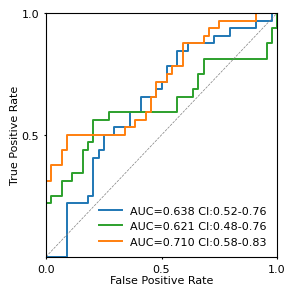

In [6]:
fig, ax = plt.subplots(figsize=(3,3))

def add_curve(color, label, y_true, y_pred):
    auc, ci_low, ci_high = Bootstrapping( pred_df[y_true], pred_df[y_pred],
            metric_str="roc_auc",
            n_bootstraps=5000,
            confidence_level=0.95,
            random_state=42,
        )
    fpr, tpr, thresholds = roc_curve(pred_df[y_true], pred_df[y_pred])
    plt.plot(fpr, tpr,
             label=f"AUC={auc:.3f} CI:{ci_low:.2f}-{ci_high:.2f}",
             color=color)

add_curve("C0", "Nuclei",'y_true','nuclei_y_pred')
add_curve("C2", "Gland",'y_true','gland_y_pred')
add_curve("C1", "SCALE3D",'y_true','graph_y_pred')

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.5, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# Keep only 0.5 tick on both axes
ax.set_xticks([0,0.5,1])
ax.set_yticks([0.5,1])

# Ensure limits are still [0, 1]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

#ax.legend()
plt.tight_layout()
legend = ax.legend(frameon=False,loc="lower right") 
frame = legend.get_frame()
frame.set_linewidth(0.5)

#plt.savefig("../figures/Fig3aleft.pdf", bbox_inches="tight")
plt.show()


Bootstrapping roc_auc: 100%|██████████| 5000/5000 [00:02<00:00, 2316.12it/s]


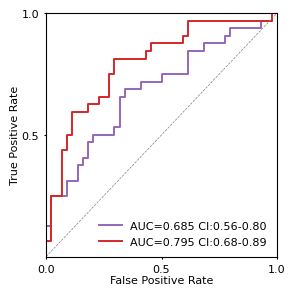

In [ ]:

fig, ax = plt.subplots(figsize=(3,3))
add_curve("C4", "Nuclei+Cancer gland",'y_true','nuclei_gland_y_pred')
add_curve("C3", "Nuclei+Cancer gland+ graph",'y_true','nuclei_gland_graph_y_pred')

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.5, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# Keep only 0.5 tick on both axes
ax.set_xticks([0,0.5,1])
ax.set_yticks([0.5,1])

# Ensure limits are still [0, 1]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

#ax.legend()
plt.tight_layout()
legend = ax.legend(frameon=False,loc="lower right") 
frame = legend.get_frame()
frame.set_linewidth(0.5)

#plt.savefig("../figures/Fig3bleft.pdf", bbox_inches="tight")
plt.show()



# Nested LOOCV statistical evaluation

## Kaplan–Meier plots for all five Cox feature sets

In [7]:
RESULT_DIR = Path('./results/cox')
MODEL_INFO = {
    'nuclei': ('Nuclei', 'C0'),
    'gland': ('Gland', 'C2'),
    'graph': ('Graph', 'C1'),
    'nuclei_gland': ('Nuclei + gland', 'C4'),
    'nuclei_gland_graph': ('Nuclei + gland + graph', 'C3'),
}
risk_groups = {}
for model in MODEL_INFO:
    path = RESULT_DIR / f'{model}_risk_groups.csv'
    df = pd.read_csv(path).sort_values('outer_fold').reset_index(drop=True)
    required = {'sample_name', 'sample_id', 'time', 'event', 'risk_score', 'outer_fold', 'risk_group'}
    if len(df) != 76 or not required.issubset(df.columns) or df['sample_id'].duplicated().any():
        raise ValueError(f'Invalid Cox risk-group table: {path}')
    risk_groups[model] = df

reference = risk_groups['nuclei'][['sample_id', 'time', 'event', 'outer_fold']]
for model, df in risk_groups.items():
    if not reference.equals(df[['sample_id', 'time', 'event', 'outer_fold']]):
        raise ValueError(f'Patient alignment differs for {model}')

print('Loaded and aligned five Cox result tables with 76 patients each.')

Loaded and aligned five Cox result tables with 76 patients each.


In [8]:

from lifelines import CoxPHFitter
from scipy.stats import chi2

df_eval = risk_groups['nuclei_gland']
df_eval["score_GN"]  = risk_groups['nuclei_gland']["risk_score"].values
df_eval["score_GNG"] = risk_groups['graph']["risk_score"].values

# reduced
cph_r = CoxPHFitter().fit(
    df_eval[["time", "event", "score_GN"]],
    duration_col="time", event_col="event"
)

# full
cph_f = CoxPHFitter().fit(
    df_eval[["time", "event", "score_GN", "score_GNG"]],
    duration_col="time", event_col="event"
)

# LRT
lrt = 2 * (cph_f.log_likelihood_ - cph_r.log_likelihood_)
p_lrt = 1 - chi2.cdf(lrt, df=1)
print(p_lrt,lrt)


0.0074506035611205945 7.160990674102891


In [9]:
def km_statistics(df):
    high = df[df['risk_group'] == 'High-risk'].copy()
    low = df[df['risk_group'] == 'Low-risk'].copy()
    logrank = logrank_test(high['time'], low['time'], event_observed_A=high['event'], event_observed_B=low['event'])
    hr_df = df[['time', 'event', 'risk_group']].copy()
    hr_df['risk_group'] = hr_df['risk_group'].map({'Low-risk': 0, 'High-risk': 1})
    cph = CoxPHFitter().fit(hr_df, duration_col='time', event_col='event')
    hr = float(np.exp(cph.params_['risk_group']))
    ci = np.exp(cph.confidence_intervals_.loc['risk_group']).to_numpy(dtype=float)
    cindex = concordance_index(df['time'], -df['risk_score'], df['event'])
    return high, low, float(logrank.p_value), hr, ci, float(cindex)

def format_p(p):
    if p < 0.0001:
        return 'p < 0.0001'
    if p < 0.001:
        return 'p < 0.001'
    return f'p = {p:.3g}'

def plot_km(ax, df, title, color):
    high, low, p, hr, ci, cindex = km_statistics(df)
    KaplanMeierFitter().fit(high['time'] / 30, high['event'], label='High Risk').plot(
        ax=ax, ci_show=False, color=color, linestyle='--')
    KaplanMeierFitter().fit(low['time'] / 30, low['event'], label='Low Risk').plot(
        ax=ax, ci_show=False, color=color, linestyle='-')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    #ax.set_xlabel('Time (months)')
    ax.set_ylabel('Recurrence-free survival')
    ax.set_xlim(0, 70)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 30, 60])
    ax.set_yticks([0, 0.5, 1])
    ax.get_legend().remove()
    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, frameon=False, handlelength=2, fontsize=8)
    ax.text(1, 0.03, f'{format_p(p)}\nHR = {hr:.2f} ({ci[0]:.2f}–{ci[1]:.2f})\nC-index = {cindex:.3f}',
            ha='left', va='bottom', fontsize=8)
    return {'model': title, 'c_index': cindex, 'hazard_ratio': hr, 'hr_ci_lower': ci[0],
            'hr_ci_upper': ci[1], 'logrank_p_value': p, 'n_high': len(high), 'n_low': len(low)}

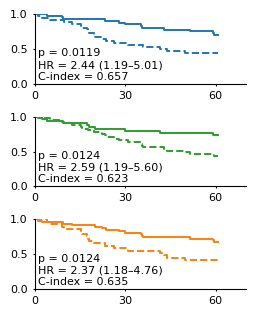

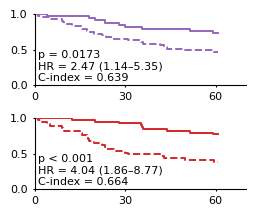

,model,c_index,hazard_ratio,hr_ci_lower,hr_ci_upper,logrank_p_value,n_high,n_low
0,Nuclei,0.656513,2.441187,1.190244,5.006870,0.011907,36,40
1,Gland,0.622899,2.586120,1.194238,5.600237,0.012406,41,35
2,Graph,0.634979,2.370222,1.180528,4.758849,0.012386,29,47
3,Nuclei + gland,0.638655,2.474839,1.143759,5.354999,0.017323,43,33
4,Nuclei + gland + graph,0.664391,4.042774,1.863982,8.768339,0.000133,37,39


In [10]:
def plot_km_group(models, figsize, filename):
    fig, axes = plt.subplots( len(models),1, figsize=figsize, sharey=True)
    results = []
    for ax, model in zip(np.atleast_1d(axes), models):
        label, color = MODEL_INFO[model]
        results.append(plot_km(ax, risk_groups[model], label, color))
    for ax in np.atleast_1d(axes)[0:]:
        ax.set_xlabel('')
        ax.set_ylabel('')
    fig.tight_layout()
    plt.show()
    return results

basic_results = plot_km_group(
    ['nuclei', 'gland', 'graph'], figsize=(2.6 , 3.2), filename='cox_nuclei_gland_graph_km')
combined_results = plot_km_group(
    ['nuclei_gland', 'nuclei_gland_graph'], figsize=(2.6 , 2.2), filename='cox_combined_feature_km')

km_summary = pd.DataFrame(basic_results + combined_results)
display(km_summary)